# Homework 6

David Godovich  
4/8/2026

In [1]:
# I don't use colab but have a fork of the class repo
# Run this to set up colab file structure
# %cd /content
# !rm -rf MOL518-Intro-to-Data-Analysis

# !git clone https://github.com/dgodovich/MOL518-Intro-to-Data-Analysis.git
# %cd MOL518-Intro-to-Data-Analysis/Homework_6

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# load in data
# tab separated, use gene names as index
expression_data = pd.read_csv('HW6_data/AEC_SARSCoV2_17AAG_readcounts.txt', sep = '\t', index_col = 0)

# set up conditions
condition_1 = [
    'AECII_19_48h_S2_DMSO-1',
    'AECII_20_48h_S2_DMSO-2',
    'AECII_21_48h_S2_DMSO-3'
]

condition_2 = [
    'AECII_22_48h_S2_200nM17AAG-1',
    'AECII_23_48h_S2_200nM17AAG-2',
    'AECII_24_48h_S2_200nM17AAG-3'
]

# only take data from desired conditions
expression_data_subset = expression_data[condition_1 + condition_2]

In [4]:
expression_data_subset.columns

Index(['AECII_19_48h_S2_DMSO-1', 'AECII_20_48h_S2_DMSO-2',
       'AECII_21_48h_S2_DMSO-3', 'AECII_22_48h_S2_200nM17AAG-1',
       'AECII_23_48h_S2_200nM17AAG-2', 'AECII_24_48h_S2_200nM17AAG-3'],
      dtype='str')

In [5]:
expression_data['width'].describe()

count     27011.000000
mean       2958.530006
std        2737.280609
min          20.000000
25%        1130.000000
50%        2345.000000
75%        4011.500000
max      116854.000000
Name: width, dtype: float64

In [6]:
# 2 - calculate RPKM values
read_length = 15 #15(e6) reads per replicate
rpkm_values = expression_data_subset.div((expression_data['width']/1000)*read_length, axis = 0)

In [7]:
# take average rpkm from replicates for each condition 
rpkm_values['condition_1'] = (rpkm_values[condition_1].sum(axis = 1))/3
rpkm_values['condition_2'] = (rpkm_values[condition_2].sum(axis = 1))/3

In [8]:
rpkm_values

,AECII_19_48h_S2_DMSO-1,AECII_20_48h_S2_DMSO-2,AECII_21_48h_S2_DMSO-3,AECII_22_48h_S2_200nM17AAG-1,AECII_23_48h_S2_200nM17AAG-2,AECII_24_48h_S2_200nM17AAG-3,condition_1,condition_2
gene,,,,,,,,
A1BG,0.490751,0.830502,0.792752,1.170253,1.359003,0.755002,0.704668,1.094753
A1BG-AS1,1.408451,1.126761,0.938967,0.907668,0.719875,0.594679,1.158059,0.740741
A1CF,0.000000,0.000000,0.000000,0.000000,0.000000,0.006996,0.000000,0.002332
A2M,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A2M-AS1,0.000000,0.000000,0.030483,0.030483,0.030483,0.000000,0.010161,0.020322
...,...,...,...,...,...,...,...,...
ZYG11A,0.000000,0.015609,0.000000,0.015609,0.000000,0.000000,0.005203,0.005203
ZYG11B,3.381643,3.733726,3.070499,5.314010,6.509457,6.083681,3.395289,5.969049
ZYX,71.346043,80.473715,68.053148,56.296938,59.098787,55.112652,73.290969,56.836126


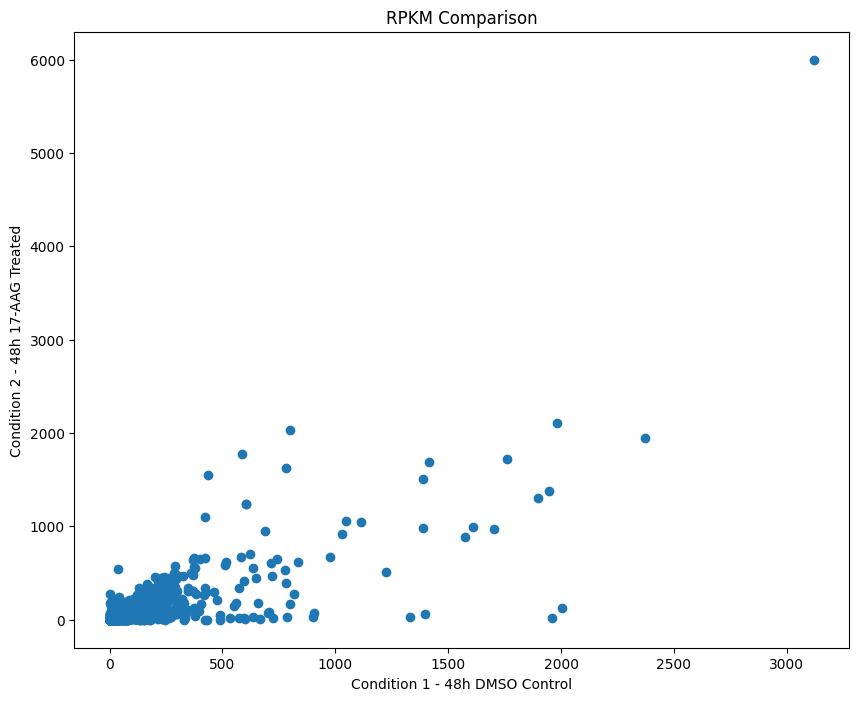

In [9]:
# 3 - plot RPKM values
fig, ax = plt.subplots(figsize = (10,8))
ax.scatter(rpkm_values['condition_1'], rpkm_values['condition_2'])
ax.set_title('RPKM Comparison')
ax.set_xlabel('Condition 1 - 48h DMSO Control')
ax.set_ylabel('Condition 2 - 48h 17-AAG Treated')
plt.show()

In [10]:
print('Number of genes expressed in 48h DMSO control replicates: ', sum(rpkm_values['condition_1'] > 0))
print('Number of genes expressed in 48h 17-AAG treated replicates: ', sum(rpkm_values['condition_2'] > 0))

Number of genes expressed in 48h DMSO control replicates:  18864
Number of genes expressed in 48h 17-AAG treated replicates:  19035


In [11]:
# 4 - fold change
rpkm_pseudocount = rpkm_values + 1

ratio = rpkm_pseudocount['condition_1']/rpkm_pseudocount['condition_2']

In [12]:
pd.options.display.max_seq_items = 200

In [13]:
print('Genes with >10 fold lower expression with 17-AAG treatment:')
print(rpkm_pseudocount[ratio > 10].index)
print('Total: ',sum(ratio > 10))

Genes with >10 fold lower expression with 17-AAG treatment:
Index(['ADAM8', 'ANGPTL4', 'APOBEC3A', 'APOBEC3A_B', 'APOBEC3G', 'APOL1',
       'ATP10A', 'BATF2', 'BST2', 'C15orf48', 'CALML5', 'CASP1', 'CD274',
       'CEACAM1', 'CFB', 'CLDN4', 'CMPK2', 'CX3CL1', 'CXCL10', 'CXCL11',
       'CXCL8', 'DDX58', 'DDX60', 'DDX60L', 'DHX58', 'DUOX2', 'DUOXA2',
       'DUSP6', 'EMP1', 'EREG', 'ETV7', 'FUT2', 'GABRP', 'GBP1', 'GBP1P1',
       'GBP4', 'GJB2', 'GMPR', 'HELZ2', 'HERC5', 'HERC6', 'HLA-F', 'HSH2D',
       'ID1', 'IDO1', 'IFI27', 'IFI35', 'IFI44', 'IFI44L', 'IFI6', 'IFIH1',
       'IFIT1', 'IFIT2', 'IFIT3', 'IFITM1', 'IFNL2', 'IFNL3', 'IGFL1', 'IL1B',
       'IRF7', 'ISG15', 'ISG20', 'KRT6A', 'KRT75', 'KRT8', 'KRTAP2-3', 'LAMP3',
       'LAP3', 'LGALS9', 'LIF', 'MALL', 'MIR147B', 'MLKL', 'MMP1', 'MMP9',
       'MT2A', 'MX1', 'MX2', 'MYEOV', 'NCCRP1', 'NLRC5', 'NT5C3A', 'OAS1',
       'OAS2', 'OAS3', 'OASL', 'PARP14', 'PARP9', 'PLAUR', 'PLEKHA4', 'PNPT1',
       'PSMB9', 'RNF213', 'RSAD2

In [14]:
print('Genes with >10 fold higher expression with 17-AAG treatment:')
print(rpkm_pseudocount[ratio < .1].index)
print('Total: ',sum(ratio < .1))

Genes with >10 fold higher expression with 17-AAG treatment:
Index(['ABHD4', 'AKR1C1', 'AKR1C2', 'CAPN6', 'CDKN1C', 'CPA4', 'CTSV',
       'CYBRD1', 'EGLN3', 'FAM129A', 'FGD3', 'FLG', 'GABARAPL1', 'GPNMB',
       'GPR176', 'LCAL1', 'LOXL4', 'METTL7A', 'NANOS1', 'NPNT', 'OLFML2A',
       'OLR1', 'PEG10', 'RAMP1', 'RARB', 'SEMA5A', 'SLC2A5', 'SLC40A1',
       'SPINK1', 'SPOCK2', 'STEAP3', 'TMEM255A'],
      dtype='str', name='gene')
Total:  32
